# SUBFASE 2: Integridad y Estructura Temporal

Objetivo de esta subfase:
1. Analizar estructura temporal real de datos transaccionales BVG
2. Cuantificar gaps de no trading en calendario diario
3. Comparar serie sin imputacion vs forward fill como analisis de sensibilidad

In [25]:
# 1) Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.stattools import acf

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid')

In [26]:
# Variables y rutas
INPUT_PATH = Path('../data/processed/BVG_Acciones_limpio.csv')

empresas_objetivo = ['CORPORACION FAVORITA C.A.', 'BANCO GUAYAQUIL S.A.']
emisor_col = 'EMISOR'
fecha_col = 'FECHA NEGOCIACIÓN'
precio_col = 'PRECIO'
vol_col = 'NÚMERO DE ACCIONES'

In [27]:
# Funciones para gaps
def construir_serie_diaria_empresa(df_src: pd.DataFrame, empresa: str) -> pd.DataFrame:
    g = df_src.loc[df_src[emisor_col] == empresa, [fecha_col, precio_col]].copy()
    diario = (
        g.sort_values(fecha_col)
        .groupby(fecha_col, as_index=True)[precio_col]
        .last()
        .to_frame(name='precio_equiv_cierre')
    )

    idx_completo = pd.date_range(diario.index.min(), diario.index.max(), freq='D')
    diario_reindex = diario.reindex(idx_completo)
    diario_reindex.index.name = 'fecha'
    diario_reindex['empresa'] = empresa
    diario_reindex['precio_A_sin_imputacion'] = diario_reindex['precio_equiv_cierre']
    diario_reindex['precio_B_ffill'] = diario_reindex['precio_equiv_cierre'].ffill()
    return diario_reindex.reset_index()

def calcular_gaps_consecutivos(mask_nan: pd.Series) -> list:
    gaps = []
    contador = 0
    for v in mask_nan.astype(bool).values:
        if v:
            contador += 1
        elif contador > 0:
            gaps.append(contador)
            contador = 0
    if contador > 0:
        gaps.append(contador)
    return gaps

In [28]:
# Cargar dataset base
df_obj = pd.read_csv(INPUT_PATH, sep=',')
df_obj[fecha_col] = pd.to_datetime(df_obj[fecha_col], errors='coerce')

## Analisis de frecuencia temporal
Para cada empresa se mide cuantas observaciones existen por fecha y si hay multiples transacciones por dia.

In [29]:
# Registros por dia en datos transaccionales
freq_diaria = (
    df_obj.groupby([emisor_col, fecha_col])
    .size()
    .rename('n_registros')
    .reset_index()
)

print('Resumen de frecuencia diaria por empresa:')
res_freq = freq_diaria.groupby(emisor_col)['n_registros'].describe()
display(res_freq)

multi_tx = freq_diaria.assign(multiple_tx=lambda x: x['n_registros'] > 1)
multi_res = multi_tx.groupby(emisor_col)['multiple_tx'].mean().rename('pct_fechas_con_multiples_tx') * 100
print('Porcentaje de fechas con multiples transacciones:')
display(multi_res.round(2))

Resumen de frecuencia diaria por empresa:


,count,mean,std,min,25%,50%,75%,max
EMISOR,,,,,,,,
BANCO GUAYAQUIL S.A.,1168.0,2.981164,2.304124,1.0,1.0,2.0,4.0,16.0
CORPORACION FAVORITA C.A.,1703.0,8.635349,7.097796,1.0,4.0,7.0,11.0,129.0


Porcentaje de fechas con multiples transacciones:


EMISOR
BANCO GUAYAQUIL S.A.         69.09
CORPORACION FAVORITA C.A.    93.07
Name: pct_fechas_con_multiples_tx, dtype: float64

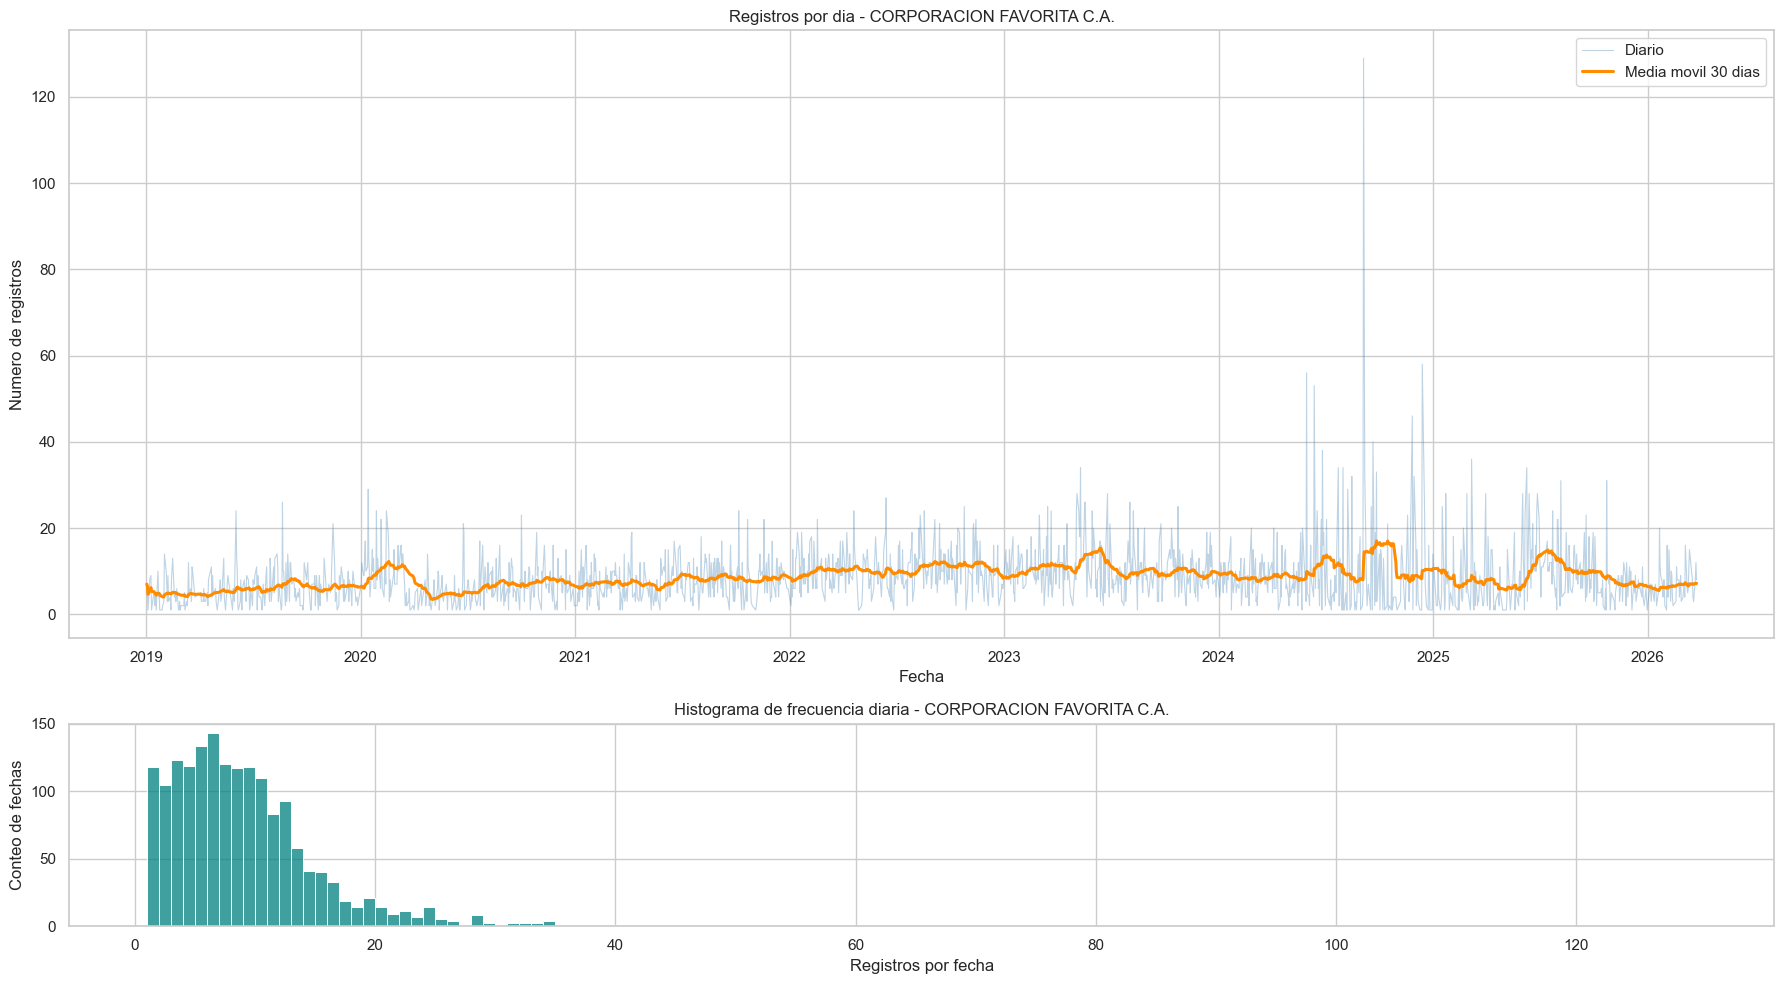

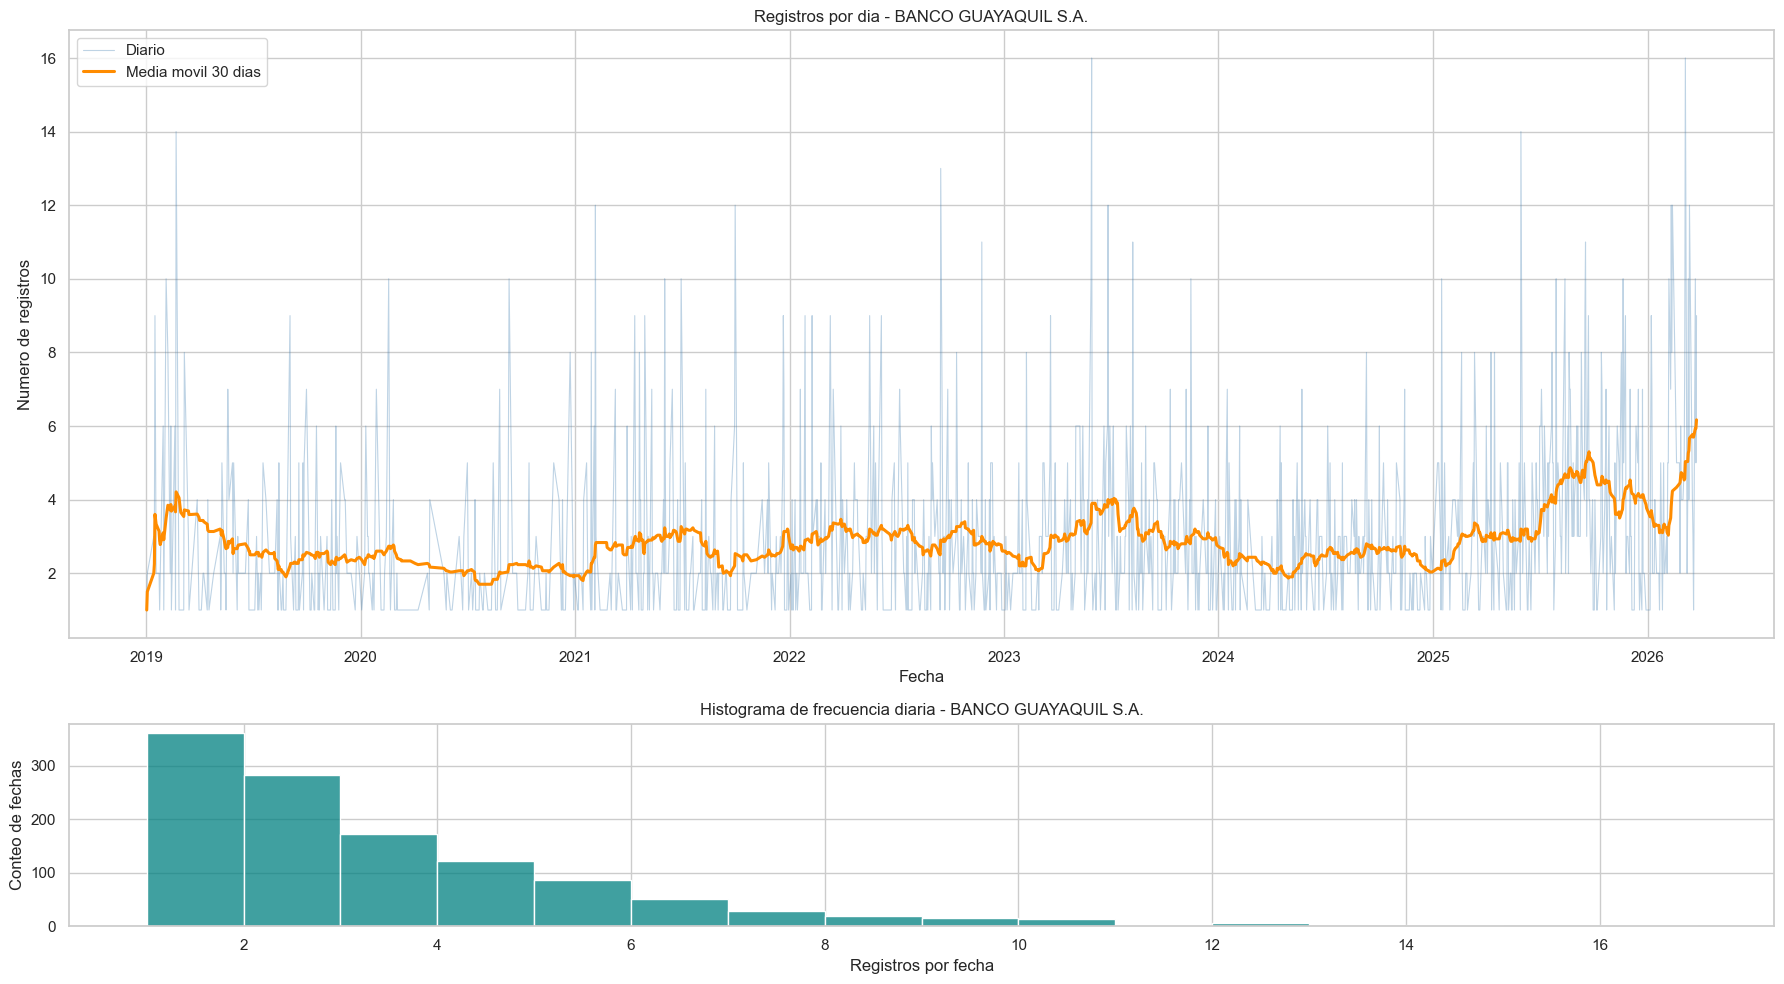

In [30]:
# Visualizaciones de frecuencia temporal por empresa
for empresa in empresas_objetivo:
    d = freq_diaria[freq_diaria[emisor_col] == empresa].copy()
    # Media movil 30 dias
    d['n_registros_ma30'] = d['n_registros'].rolling(30, min_periods=1).mean()

    fig, axes = plt.subplots(
        2, 1,
        figsize=(18, 10),
        gridspec_kw={'height_ratios': [3, 1]}
    )

    # Serie diaria + media movil 30 dias
    sns.lineplot(
        data=d, x=fecha_col, y='n_registros',
        ax=axes[0], linewidth=0.8, alpha=0.35, color='steelblue', label='Diario'
    )
    sns.lineplot(
        data=d, x=fecha_col, y='n_registros_ma30',
        ax=axes[0], linewidth=2.2, color='darkorange', label='Media movil 30 dias'
    )
    axes[0].set_title(f'Registros por dia - {empresa}')
    axes[0].set_xlabel('Fecha')
    axes[0].set_ylabel('Numero de registros')
    axes[0].legend()

    # Histograma de frecuencia diaria
    max_reg = int(d['n_registros'].max())
    bins = range(1, max_reg + 2) if max_reg > 1 else 10
    sns.histplot(data=d, x='n_registros', bins=bins, kde=False, ax=axes[1], color='teal')
    axes[1].set_title(f'Histograma de frecuencia diaria - {empresa}')
    axes[1].set_xlabel('Registros por fecha')
    axes[1].set_ylabel('Conteo de fechas')

    plt.tight_layout()
    plt.show()

## Reindexacion a frecuencia diaria
Se construye una serie diaria completa por empresa desde fecha minima hasta maxima.
En esta etapa, los dias sin trading se mantienen como NaN para la columna de precio A, y forward filling para precio B.

In [31]:
# Construccion de serie diaria completa
series_diarias = [construir_serie_diaria_empresa(df_obj, empresa) for empresa in empresas_objetivo]
df_diario = pd.concat(series_diarias, ignore_index=True)

print('Vista general del dataset diario reindexado:')
display(df_diario.head())
print('Filas totales reindexadas:', len(df_diario))

Vista general del dataset diario reindexado:


,fecha,precio_equiv_cierre,empresa,precio_A_sin_imputacion,precio_B_ffill
0,2019-01-02,2.44,CORPORACION FAVORITA C.A.,2.44,2.44
1,2019-01-03,2.46,CORPORACION FAVORITA C.A.,2.46,2.46
2,2019-01-04,2.44,CORPORACION FAVORITA C.A.,2.44,2.44
3,2019-01-05,NaN,CORPORACION FAVORITA C.A.,NaN,2.44
4,2019-01-06,NaN,CORPORACION FAVORITA C.A.,NaN,2.44


Filas totales reindexadas: 5280


## Analisis de gaps
Se cuantifican dias faltantes y longitudes de gaps consecutivos en la version sin imputacion.

In [32]:
resumen_gaps = []
gap_lengths_all = []

for empresa in empresas_objetivo:
    d = df_diario[df_diario['empresa'] == empresa].copy()
    is_gap = d['precio_A_sin_imputacion'].isna()
    gaps = calcular_gaps_consecutivos(is_gap)

    resumen_gaps.append({
        'empresa': empresa,
        'dias_totales_reindexados': len(d),
        'dias_sin_trading': int(is_gap.sum()),
        'pct_dias_sin_trading': round(is_gap.mean() * 100, 2),
        'n_gaps_consecutivos': len(gaps),
        'mediana_gap': float(np.median(gaps)) if len(gaps) > 0 else 0.0,
        'p90_gap': float(np.quantile(gaps, 0.9)) if len(gaps) > 0 else 0.0,
        'max_gap': int(np.max(gaps)) if len(gaps) > 0 else 0
    })

    for g in gaps:
        gap_lengths_all.append({'empresa': empresa, 'longitud_gap': g})

resumen_gaps_df = pd.DataFrame(resumen_gaps)
gap_lengths_df = pd.DataFrame(gap_lengths_all)

display(resumen_gaps_df)

,empresa,dias_totales_reindexados,dias_sin_trading,pct_dias_sin_trading,n_gaps_consecutivos,mediana_gap,p90_gap,max_gap
0,CORPORACION FAVORITA C.A.,2640,937,35.49,418,2.0,3.0,9
1,BANCO GUAYAQUIL S.A.,2640,1472,55.76,507,2.0,5.0,23


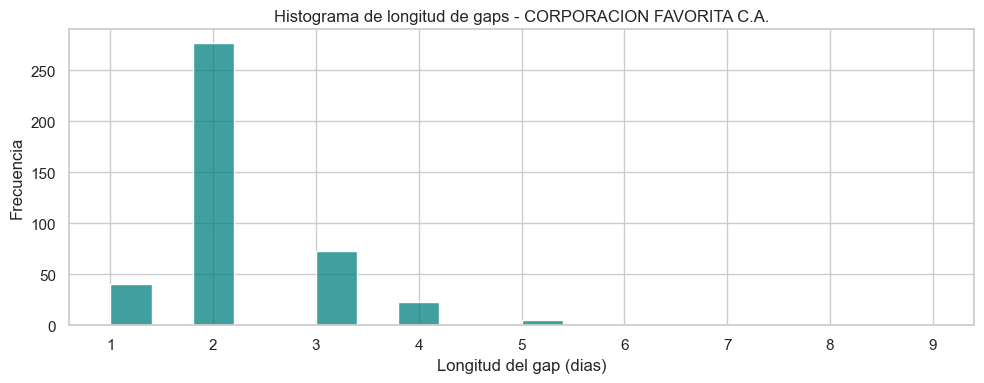

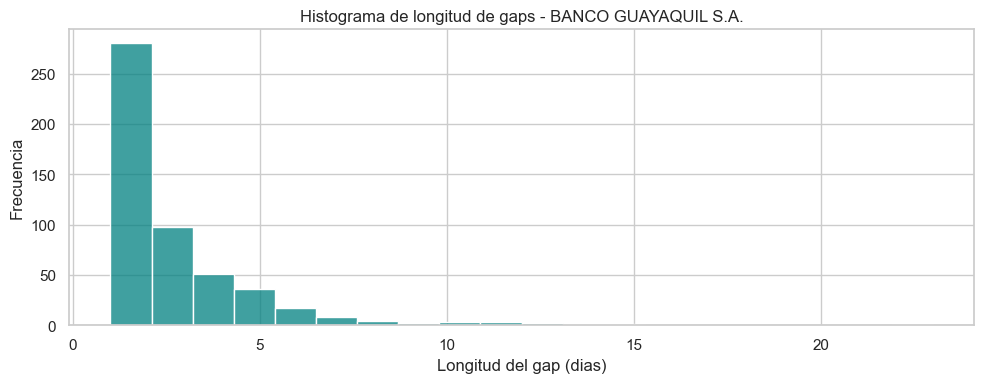

In [33]:
# Visualizacion de gaps por empresa
for empresa in empresas_objetivo:
    d_gap = gap_lengths_df[gap_lengths_df['empresa'] == empresa].copy()

    plt.figure(figsize=(10, 4))
    sns.histplot(d_gap['longitud_gap'], bins=20, color='teal')
    plt.title(f'Histograma de longitud de gaps - {empresa}')
    plt.xlabel('Longitud del gap (dias)')
    plt.ylabel('Frecuencia')


    plt.tight_layout()
    plt.show()

## Comparativa de datasets
Se calculan retornos logaritmicos para:
- Dataset A: sin imputacion (NaN en dias sin trading)
- Dataset B: con forward filling solo en precio

In [34]:
# Retornos logaritmicos y volatilidad rolling
ventana_vol = 5

comparativos = []
for empresa in empresas_objetivo:
    d = df_diario[df_diario['empresa'] == empresa].copy().sort_values('fecha')

    # Dataset A: conserva NaN donde no hubo trading
    d['ret_A'] = np.log(d['precio_A_sin_imputacion'] / d['precio_A_sin_imputacion'].shift(1))

    # Dataset B: ffill en precio, luego retorno
    d['ret_B'] = np.log(d['precio_B_ffill'] / d['precio_B_ffill'].shift(1))

    d['vol_A'] = d['ret_A'].rolling(ventana_vol).std()
    d['vol_B'] = d['ret_B'].rolling(ventana_vol).std()

    comparativos.append(d)

df_comp = pd.concat(comparativos, ignore_index=True)
display(df_comp.head())

,fecha,precio_equiv_cierre,empresa,precio_A_sin_imputacion,precio_B_ffill,ret_A,ret_B,vol_A,vol_B
0,2019-01-02,2.44,CORPORACION FAVORITA C.A.,2.44,2.44,NaN,NaN,NaN,NaN
1,2019-01-03,2.46,CORPORACION FAVORITA C.A.,2.46,2.46,0.008163,0.008163,NaN,NaN
2,2019-01-04,2.44,CORPORACION FAVORITA C.A.,2.44,2.44,-0.008163,-0.008163,NaN,NaN
3,2019-01-05,NaN,CORPORACION FAVORITA C.A.,NaN,2.44,NaN,0.000000,NaN,NaN
4,2019-01-06,NaN,CORPORACION FAVORITA C.A.,NaN,2.44,NaN,0.000000,NaN,NaN


In [35]:
# Estadisticos de retornos
rows_stats = []
rows_acf = []

for empresa in empresas_objetivo:
    d = df_comp[df_comp['empresa'] == empresa].copy()

    for label, col in [('A_sin_imputacion', 'ret_A'), ('B_ffill', 'ret_B')]:
        s = d[col].dropna()
        if len(s) == 0:
            continue

        rows_stats.append({
            'empresa': empresa,
            'dataset': label,
            'n': len(s),
            'mean': s.mean(),
            'std': s.std(),
            'skew': s.skew(),
            'kurtosis': s.kurtosis()
        })

        acf_vals = acf(s, nlags=10, fft=True, missing='drop')
        for lag in range(1, 11):
            rows_acf.append({
                'empresa': empresa,
                'dataset': label,
                'lag': lag,
                'acf': acf_vals[lag]
            })

stats_df = pd.DataFrame(rows_stats)
acf_df = pd.DataFrame(rows_acf)

print('Estadisticos de retornos A vs B:')
display(stats_df)

print('ACF lags 1-10 (A vs B):')
display(acf_df.pivot_table(index=['empresa', 'lag'], columns='dataset', values='acf'))

Estadisticos de retornos A vs B:


,empresa,dataset,n,mean,std,skew,kurtosis
0,CORPORACION FAVORITA C.A.,A_sin_imputacion,1284,-0.000141,0.014862,-0.799007,28.924857
1,CORPORACION FAVORITA C.A.,B_ffill,2639,-0.000075,0.012656,-1.390652,46.605589
2,BANCO GUAYAQUIL S.A.,A_sin_imputacion,660,0.001138,0.030184,-0.067345,17.239433
3,BANCO GUAYAQUIL S.A.,B_ffill,2639,0.000328,0.020402,-0.470071,36.119131


ACF lags 1-10 (A vs B):


dataset                        A_sin_imputacion   B_ffill
empresa                   lag                            
BANCO GUAYAQUIL S.A.      1           -0.139491 -0.159471
                          2            0.027048 -0.085480
                          3            0.059094 -0.054093
                          4           -0.086541 -0.038377
                          5           -0.030254  0.006504
                          6            0.059667 -0.008462
                          7           -0.015492 -0.057154
                          8            0.102589 -0.029075
                          9            0.060097  0.026225
                          10          -0.038351 -0.014786
CORPORACION FAVORITA C.A. 1           -0.257296 -0.239104
                          2            0.082734 -0.018612
                          3            0.008146 -0.069313
                          4            0.013958 -0.035643
                          5            0.022992  0.034183
                          6           -0.025340  0.066483
                          7            0.003074 -0.028255
                          8            0.025299 -0.038261
                          9           -0.041789  0.030966
                          10           0.015644 -0.013092

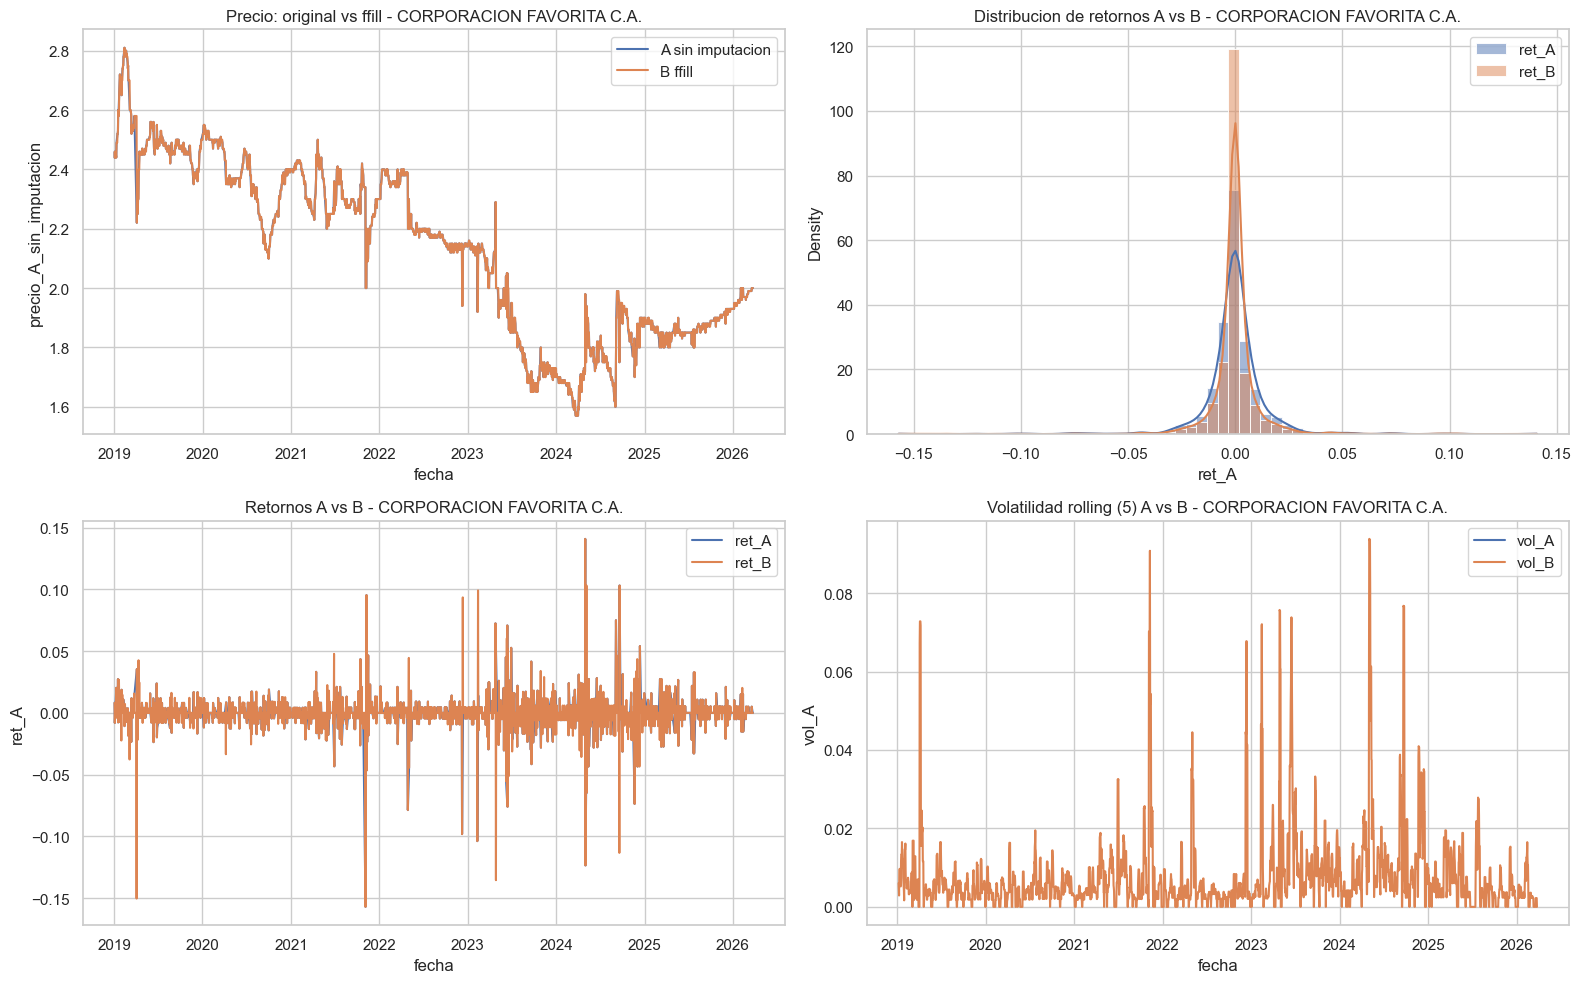

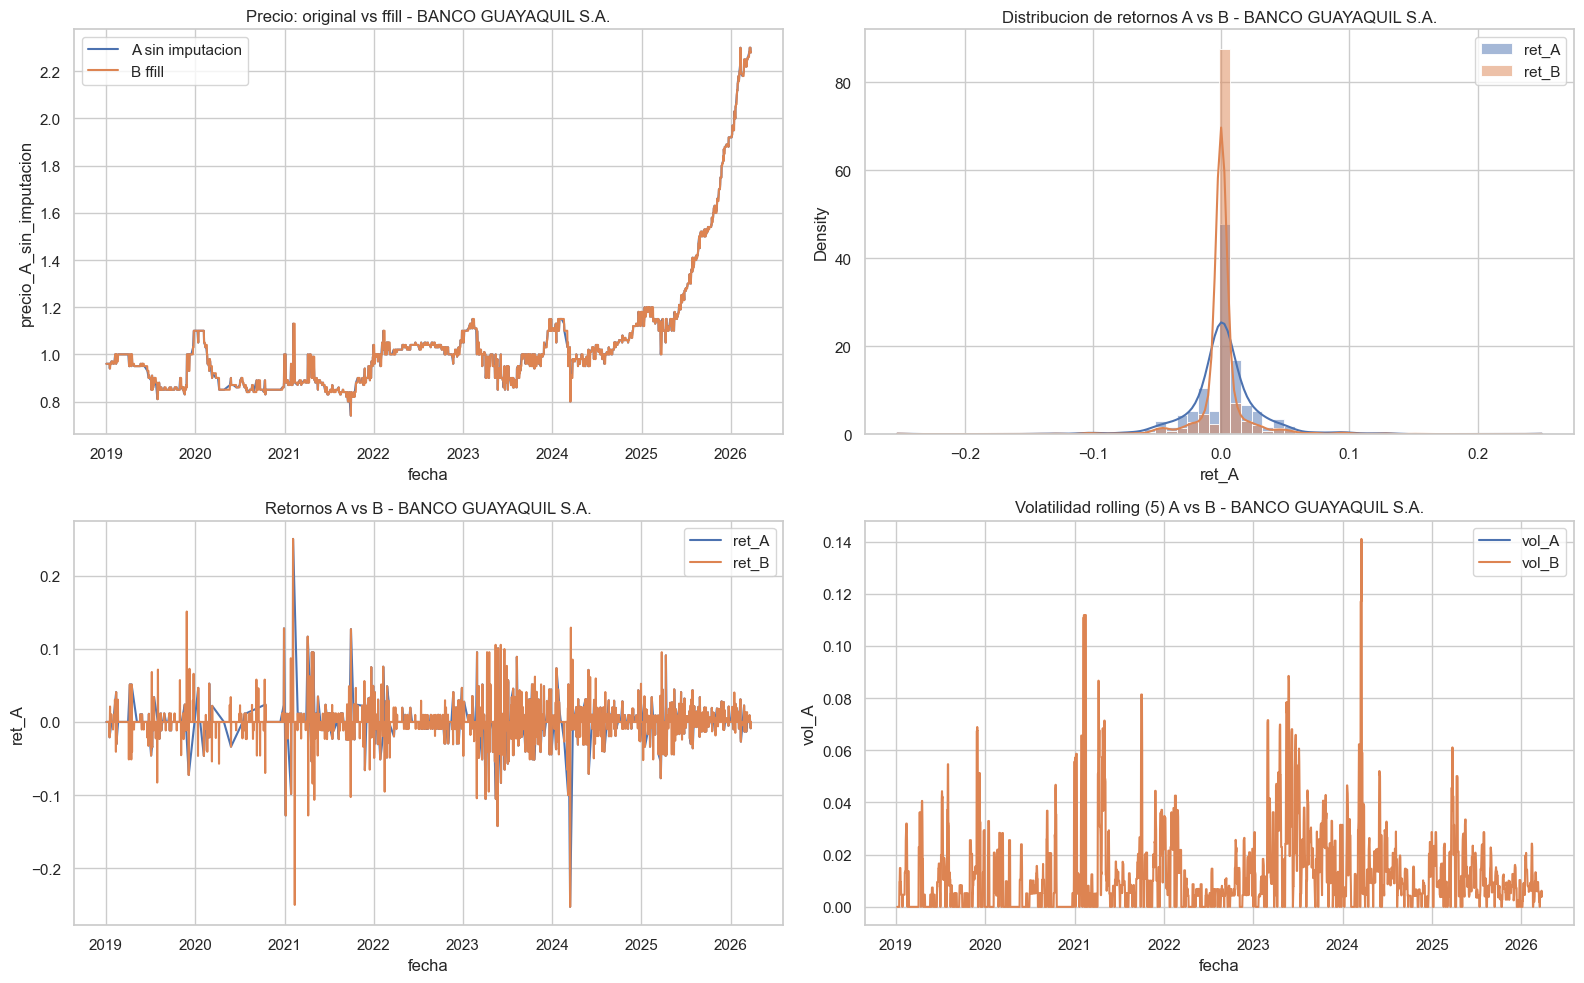

In [36]:
# Visualizaciones comparativas A vs B por empresa
for empresa in empresas_objetivo:
    d = df_comp[df_comp['empresa'] == empresa].copy().sort_values('fecha')

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Precio original vs ffill
    sns.lineplot(data=d, x='fecha', y='precio_A_sin_imputacion', ax=axes[0, 0], label='A sin imputacion')
    sns.lineplot(data=d, x='fecha', y='precio_B_ffill', ax=axes[0, 0], label='B ffill')
    axes[0, 0].set_title(f'Precio: original vs ffill - {empresa}')

    # Histograma retornos
    sns.histplot(d['ret_A'].dropna(), bins=60, stat='density', alpha=0.5, ax=axes[0, 1], label='ret_A', kde=True)
    sns.histplot(d['ret_B'].dropna(), bins=60, stat='density', alpha=0.5, ax=axes[0, 1], label='ret_B', kde=True)
    axes[0, 1].set_title(f'Distribucion de retornos A vs B - {empresa}')
    axes[0, 1].legend()

    # Serie retornos
    sns.lineplot(data=d, x='fecha', y='ret_A', ax=axes[1, 0], label='ret_A')
    sns.lineplot(data=d, x='fecha', y='ret_B', ax=axes[1, 0], label='ret_B')
    axes[1, 0].set_title(f'Retornos A vs B - {empresa}')

    # Volatilidad rolling
    sns.lineplot(data=d, x='fecha', y='vol_A', ax=axes[1, 1], label='vol_A')
    sns.lineplot(data=d, x='fecha', y='vol_B', ax=axes[1, 1], label='vol_B')
    axes[1, 1].set_title(f'Volatilidad rolling ({ventana_vol}) A vs B - {empresa}')

    plt.tight_layout()
    plt.show()

## Resumen de resultados
La siguiente celda sintetiza hallazgos cuantitativos para evaluar si ffill introduce senal artificial.

In [37]:
# Analisis critico cuantitativo por empresa
conclusiones = []

for empresa in empresas_objetivo:
    s = stats_df[stats_df['empresa'] == empresa].set_index('dataset')
    a = acf_df[(acf_df['empresa'] == empresa) & (acf_df['dataset'] == 'A_sin_imputacion')]
    b = acf_df[(acf_df['empresa'] == empresa) & (acf_df['dataset'] == 'B_ffill')]
    g = resumen_gaps_df[resumen_gaps_df['empresa'] == empresa].iloc[0]

    std_A = float(s.loc['A_sin_imputacion', 'std'])
    std_B = float(s.loc['B_ffill', 'std'])
    delta_std_pct = ((std_B - std_A) / std_A * 100) if std_A != 0 else np.nan

    mean_abs_acf_A = float(a['acf'].abs().mean()) if not a.empty else np.nan
    mean_abs_acf_B = float(b['acf'].abs().mean()) if not b.empty else np.nan
    delta_acf = mean_abs_acf_B - mean_abs_acf_A

    # Regla de decision local
    # Si baja mucho la dispersion y aumenta autocorrelacion, sospecha de suavizado artificial
    flag_suavizado = (delta_std_pct < -10) and (delta_acf > 0.01)

    conclusion_local = 'ffill potencialmente introduce senal artificial' if flag_suavizado else 'efecto de ffill acotado o no concluyente'

    conclusiones.append({
        'empresa': empresa,
        'pct_dias_sin_trading': g['pct_dias_sin_trading'],
        'max_gap': g['max_gap'],
        'std_A': std_A,
        'std_B': std_B,
        'delta_std_pct': delta_std_pct,
        'mean_abs_acf_A': mean_abs_acf_A,
        'mean_abs_acf_B': mean_abs_acf_B,
        'delta_acf': delta_acf,
        'diagnostico': conclusion_local
    })

conclusiones_df = pd.DataFrame(conclusiones)
display(conclusiones_df)

,empresa,pct_dias_sin_trading,max_gap,std_A,std_B,delta_std_pct,mean_abs_acf_A,mean_abs_acf_B,delta_acf,diagnostico
0,CORPORACION FAVORITA C.A.,35.49,9,0.014862,0.012656,-14.843744,0.049627,0.057391,0.007764,efecto de ffill acotado o no concluyente
1,BANCO GUAYAQUIL S.A.,55.76,23,0.030184,0.020402,-32.409288,0.061862,0.047963,-0.013900,efecto de ffill acotado o no concluyente


## Conclusiones de subfase

- Serie principal para modelado: **sin imputacion (Dataset A)** preservando la dinámica real del mercado.
- Existe alta proporción de dias sin trading, especialmente en BANCO GUAYAQUIL S.A.
- El ffill reduce dispersion de retornos e incrementa tamaño de muestra de forma artificial.